# Customer Churn Analysis & Prediction

**Project Type:** Exploratory Data Analysis + Machine Learning  
**Domain:** Telecommunications / Customer Retention  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## Objective
Analyze customer behavior in a telecommunications dataset, identify patterns associated with churn, and build a machine-learning model to predict whether a customer is likely to leave.

The project covers:
- Data loading and quality checks
- Exploratory data analysis
- Missing-value handling
- Categorical feature encoding
- Train/test splitting
- Random Forest classification
- Accuracy, precision, recall, F1-score and ROC-AUC
- Confusion matrix
- Feature importance
- Business-oriented retention insights

## Dataset

The project uses the **Telco Customer Churn** dataset. The dataset contains customer demographics, subscribed services, contract information, payment method, tenure, monthly charges, total charges, and churn status.

The notebook loads the public dataset from IBM's archived GitHub sample repository so the raw dataset does not need to be committed to this portfolio repository.

**Target variable:** `Churn` (`Yes` / `No`)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [17]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_URL)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Standardize column names and inspect the dataset
df.columns = df.columns.str.strip()

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Missing values:


,missing_count
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows: 0


In [19]:
# TotalCharges may contain blank strings, so convert it to numeric.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Strip whitespace from text columns.
object_cols = df.select_dtypes(include="object").columns
for col in object_cols:
    df[col] = df[col].str.strip()

print("Missing values after TotalCharges conversion:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

Missing values after TotalCharges conversion:


,missing_count
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


## Exploratory Data Analysis

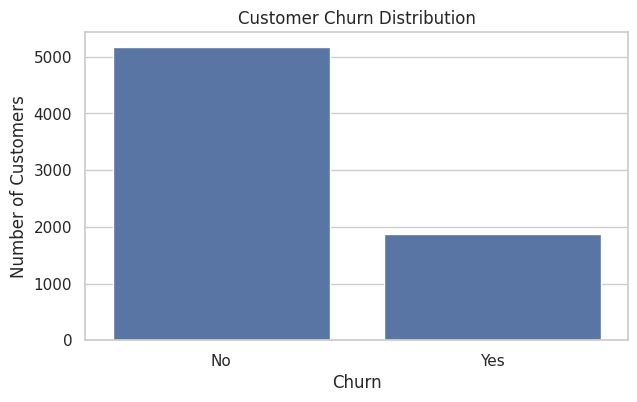

Overall churn rate: 26.54%


In [20]:
# Churn distribution
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

churn_rate = (df["Churn"].eq("Yes").mean()) * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

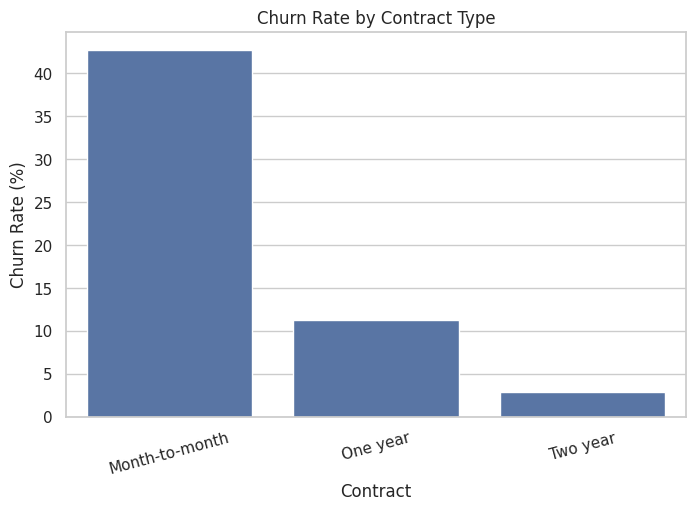

,churn_rate_percent
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


In [21]:
# Churn by contract type
contract_churn = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"]
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

display(contract_churn.to_frame("churn_rate_percent"))

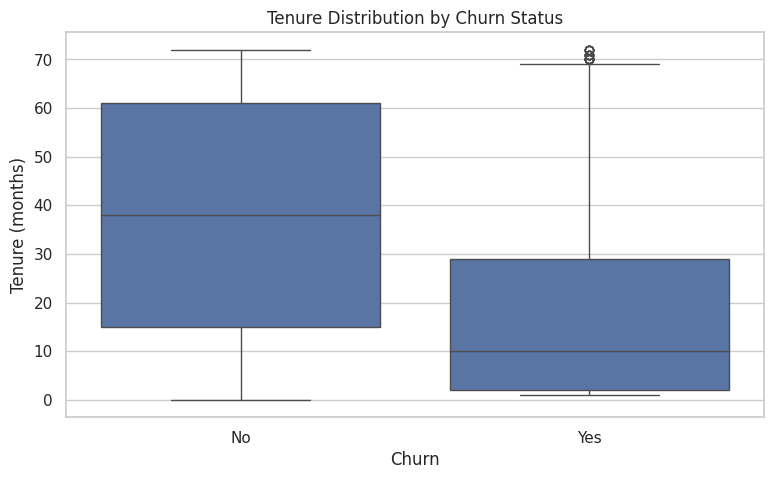

In [22]:
# Churn by tenure
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

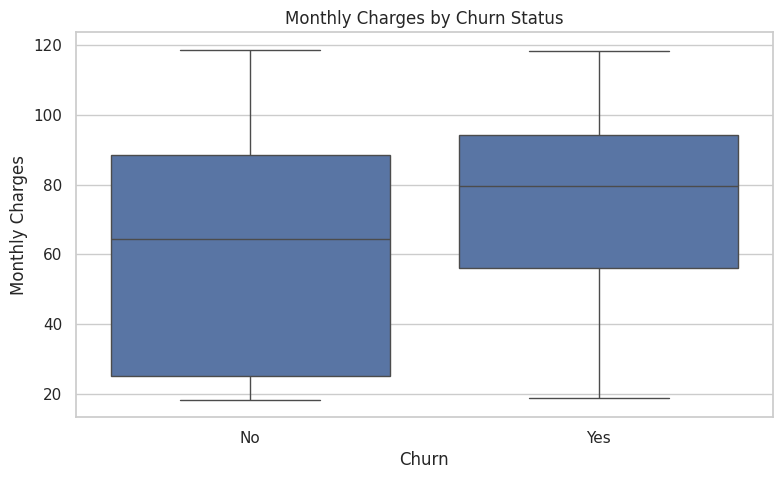

In [23]:
# Monthly charges vs churn
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## Data Preparation & Model Pipeline

In [24]:
# Remove customerID because it is an identifier rather than a predictive feature.
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [25]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

Training rows: 5634
Testing rows:  1409


In [26]:
# Random Forest classifier
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

## Model Evaluation

In [27]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

Accuracy : 0.781
ROC-AUC  : 0.822

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1035
       Churn       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



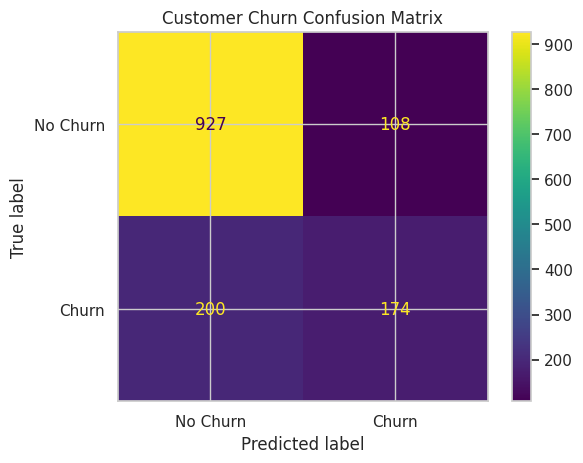

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.title("Customer Churn Confusion Matrix")
plt.show()

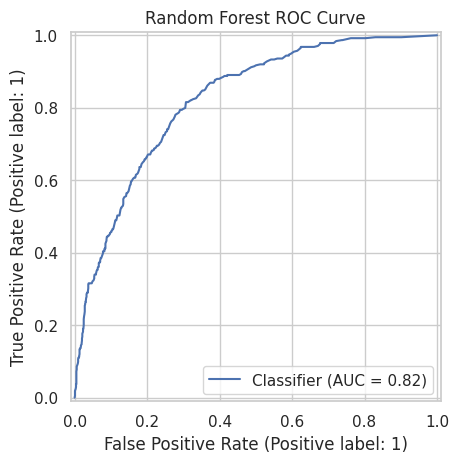

In [29]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Random Forest ROC Curve")
plt.show()

## Feature Importance

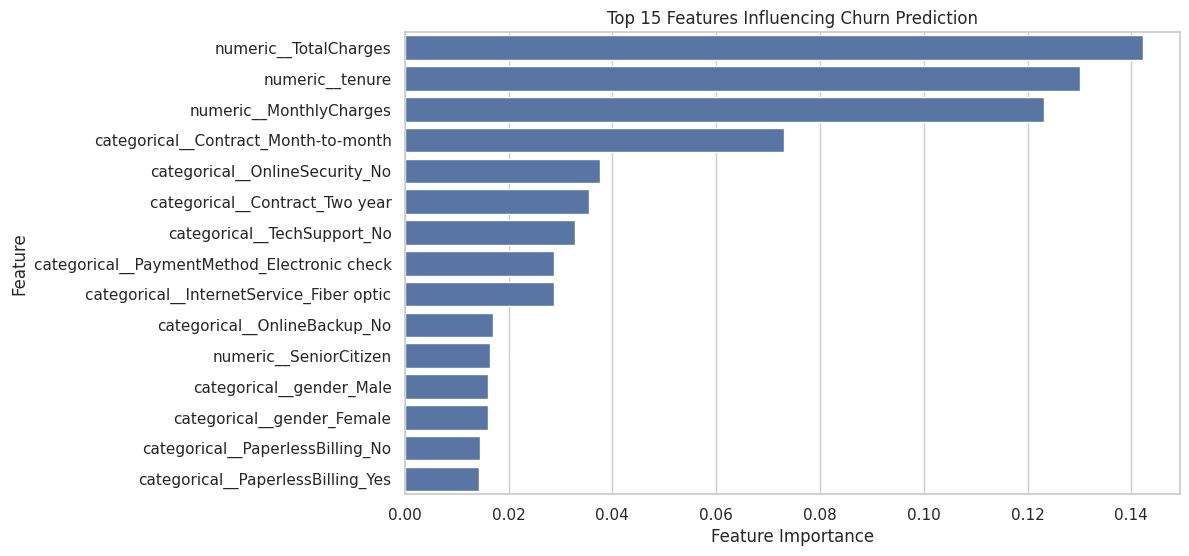

,feature,importance
3,numeric__TotalCharges,0.142224
1,numeric__tenure,0.130183
2,numeric__MonthlyCharges,0.123131
36,categorical__Contract_Month-to-month,0.073013
18,categorical__OnlineSecurity_No,0.037625
38,categorical__Contract_Two year,0.035425
27,categorical__TechSupport_No,0.032842
43,categorical__PaymentMethod_Electronic check,0.028849
16,categorical__InternetService_Fiber optic,0.028671
21,categorical__OnlineBackup_No,0.016929


In [30]:
# Extract transformed feature names and Random Forest importance.
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)
plt.title("Top 15 Features Influencing Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

display(importance_df)

## Business Interpretation

Use the model output together with the EDA rather than treating prediction as the final answer.

Typical retention actions that can be investigated include:
- Prioritizing customers on short-term/month-to-month contracts for retention campaigns.
- Monitoring customers with high monthly charges.
- Reviewing early-tenure customers for onboarding or service-quality interventions.
- Investigating service combinations associated with higher churn.
- Using predicted churn probability to prioritize limited retention resources.

**Important:** These are analytical hypotheses, not causal conclusions. Further testing is required before applying retention actions commercially.

## Conclusion

This project demonstrates an end-to-end customer churn workflow:

**Raw Data → Data Quality → EDA → Preprocessing → Random Forest → Evaluation → Feature Importance → Business Insights**

The notebook is designed as a portfolio project and can be extended with:
- Logistic Regression and XGBoost comparison
- Hyperparameter tuning
- Precision/recall optimization for retention use cases
- SHAP-based model explainability
- A Streamlit churn-risk dashboard